Weights : [1.1206146  1.16062489]
Bias : -0.06600000000000004
Accuracy : 1.0


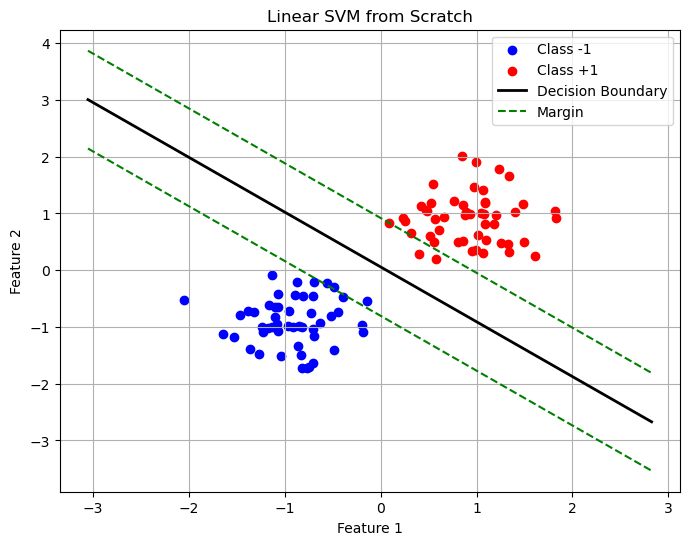

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Generate Sample Dataset
np.random.seed(42)
# Class -1
X1 = np.random.randn(50,2) + np.array([2,2])
# Class +1
X2 = np.random.randn(50,2) + np.array([6,6])
X = np.vstack((X1,X2))
y = np.hstack((-np.ones(50), np.ones(50)))
# Feature Scaling
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean) / std
# SVM Parameters
learning_rate = 0.001
lambda_param = 0.01
epochs = 1000
# Initialize Weights and Bias
w = np.zeros(X.shape[1])
b = 0
# Training
for epoch in range(epochs):
    for i, x_i in enumerate(X):
        condition = y[i] * (np.dot(x_i, w) + b) >= 1
        if condition:
            dw = 2 * lambda_param * w
            db = 0
        else:
            dw = 2 * lambda_param * w - y[i] * x_i
            db = -y[i]
        w = w - learning_rate * dw
        b = b - learning_rate * db
# Prediction
predictions = np.sign(np.dot(X, w) + b)
# Accuracy
accuracy = np.mean(predictions == y)
print("Weights :", w)
print("Bias :", b)
print("Accuracy :", accuracy)
# Visualization
plt.figure(figsize=(8,6))
plt.scatter(
    X[y==-1][:,0],
    X[y==-1][:,1],
    color='blue',
    label='Class -1'
)
plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    color='red',
    label='Class +1'
)
# Decision Boundary
x1 = np.linspace(np.min(X[:,0])-1, np.max(X[:,0])+1,100)
decision = -(w[0]*x1 + b)/w[1]
margin1 = -(w[0]*x1 + b -1)/w[1]
margin2 = -(w[0]*x1 + b +1)/w[1]
plt.plot(x1, decision, 'k-', linewidth=2, label='Decision Boundary')
plt.plot(x1, margin1, 'g--', label='Margin')
plt.plot(x1, margin2, 'g--')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM from Scratch")
plt.legend()
plt.grid(True)
plt.show()